In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [10]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label='' ):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self.label = label
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __repr__(self):
        return f"Value(data = {self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    #refer the tanh function from the 2.png file
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    def backward(self):
        # traverse all the previous nodes in reverse topological order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        # go one node at a time and call backward on it
        for node in reversed(topo):
            node._backward()
        
        

In [3]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

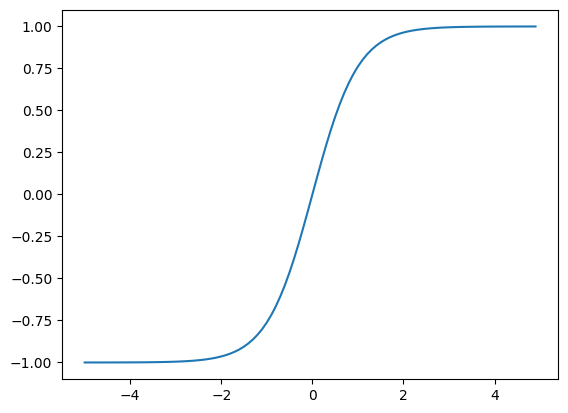

In [4]:
# tanh graph
plt.plot(np.arange(-5, 5, 0.1), np.tanh(np.arange(-5, 5, 0.1)))

In [5]:
#x1 and x2 are the imputs to neuron, w1 and w2 are the weights, b is the bias
#given in the 1.png
x1 = Value(2.0 , label='x1')
x2 = Value(0.0 , label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0 , label='w2')
b = Value(6.8813735870195432 , label='b')

# now next step is to calculate the output of the neuron, which is given by the formula
# output = x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
#finally the output of the neuron is given by
n = x1w1x2w2 + b; n.label = 'n'
# now we have the output of the neuron, we can apply the activation function to it, which is given by the formula
o = n.tanh(); o.label = 'o'



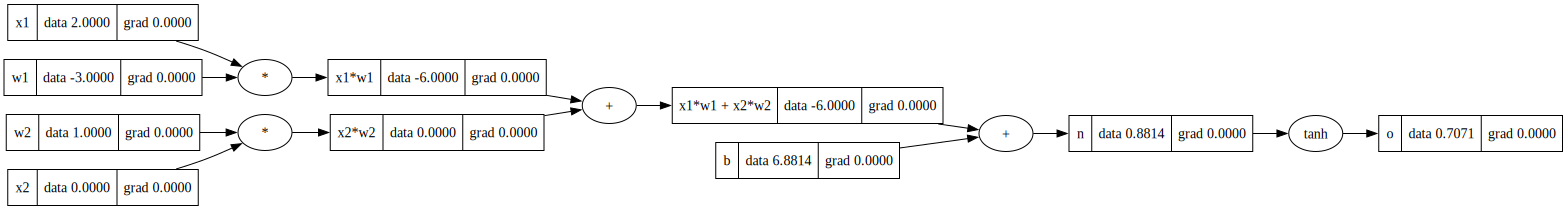

In [6]:
# create the graph object
dot = draw_dot(o)
dot

In [ ]:
# till this point we have created the computational graph for the neuron,
# now we will perform backpropagation to calculate the gradients of the inputs and weights with respect to the output.
# manually we will calculate the gradients of the output with respect to the inputs and weights, 
# and then we will use these gradients to update the weights and inputs.

# gradient of the output with respect to itself is 1
o.grad = 1.0


In [ ]:
# so now 
# o = tanh(n)
# do / dn = 1 - tanh^2(n)
# do / dn = 1 - o^2
'''
1 - o.data**2
'''


0.4999999999999999

In [ ]:
# n.grad = 0.5

In [ ]:
# And the grad of x1w1x2w2 with respect to n is 1, and the grad of b with respect to n is 1, so we can calculate the grad of x1w1 and x2w2 with respect to n as follows
'''
x1w1x2w2.grad = n.grad * 1.0
b.grad = n.grad * 1.0
'''

In [ ]:
# same goes for x1w1 and x2w2, the grad of x1w1 with respect to n is 1, and the grad of x2w2 with respect to n is 1, so we can calculate the grad of x1 and w1 with respect to n as follows
'''
x1w1.grad = x1w1x2w2.grad * 1.0
x2w2.grad = x1w1x2w2.grad * 1.0
'''

In [ ]:
# Now we can calculate the grad of x1 and w1 with respect to n as follows
'''
x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data
'''

In [ ]:
# Now we can calculate the grad of x2 and w2 with respect to n as follows
'''
x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data
'''

In [7]:
# now we have done the backpropagation maually but we can do it automate

o.backward()

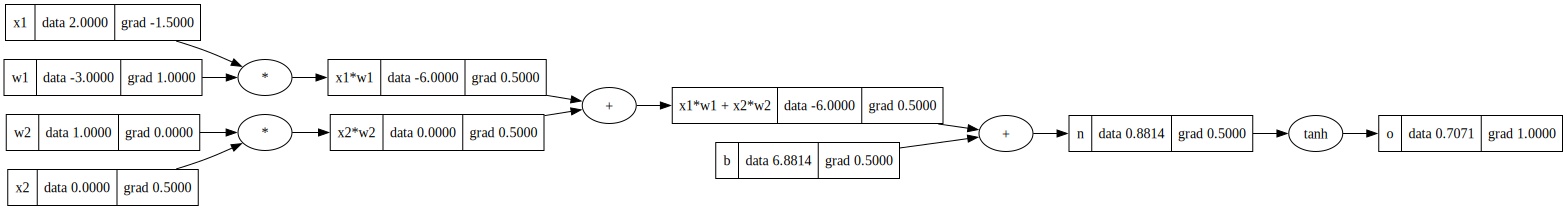

In [11]:
dot = draw_dot(o)
dot

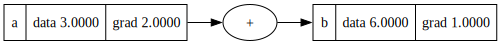

In [ ]:
#taking input same to check if gradients are being calculated correctly or not
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

'''
we have done += instead of = because we want to accumulate the gradients,
if we do = then we will overwrite the gradients and we will lose the previous gradients, 
but if we do += then we will accumulate the gradients and we will get the correct gradients.
self.grad += 1.0 * out.grad
other.grad += 1.0 * out.grad
'''